In [3]:
from scipy.io import loadmat
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras import mixed_precision
from keras.applications import efficientnet_v2
from keras.applications.efficientnet_v2 import preprocess_input as preprocess_input_eff

In [4]:
meta = loadmat("../stanford-cars/car_devkit/devkit/cars_meta.mat", simplify_cells=True)
train = loadmat("../stanford-cars/car_devkit/devkit/cars_train_annos.mat", simplify_cells=True)
test = loadmat("../stanford-cars/car_devkit/devkit/cars_test_annos.mat", simplify_cells=True)

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 196

In [6]:
class_names = meta["class_names"]

print(class_names[:10])

['AM General Hummer SUV 2000' 'Acura RL Sedan 2012' 'Acura TL Sedan 2012'
 'Acura TL Type-S 2008' 'Acura TSX Sedan 2012' 'Acura Integra Type R 2001'
 'Acura ZDX Hatchback 2012' 'Aston Martin V8 Vantage Convertible 2012'
 'Aston Martin V8 Vantage Coupe 2012'
 'Aston Martin Virage Convertible 2012']


In [7]:
annotations = train["annotations"]

print(annotations[0])

{'bbox_x1': 39, 'bbox_y1': 116, 'bbox_x2': 569, 'bbox_y2': 375, 'class': 14, 'fname': '00001.jpg'}


In [8]:
rows = []

for ann in annotations:
    class_id = int(ann["class"])
    image_name = ann["fname"]

    rows.append({
        "image": image_name,
        "class_id": class_id,
        "class_name": class_names[class_id - 1]
    })

df = pd.DataFrame(rows)
df['label'] = df['class_id'] - 1
df['file_path'] = "../stanford-cars/cars_train/cars_train/" + df['image']
df.head()
df['class_name'].value_counts().describe()

count    196.00000
mean      41.55102
std        4.33382
min       24.00000
25%       39.75000
50%       42.00000
75%       44.00000
max       68.00000
Name: count, dtype: float64

In [9]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False
for layer in base_model.layers[:-5]:
    layer.trainable = False
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(NUM_CLASSES, dtype="float32", activation='softmax'),
])

I0000 00:00:1787365301.044987    1322 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 196)            │       401,604 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,989,316 (91.51 MB)

 Trainable params: 401,604 (1.53 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])
print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")

Training images: 6515
Validation images: 1629


In [13]:
train_df.head()

,image,class_id,class_name,label,file_path
5685,05686.jpg,85,Dodge Caravan Minivan 1997,84,../stanford-cars/cars_train/cars_train/05686.jpg
7687,07688.jpg,164,Mercedes-Benz E-Class Sedan 2012,163,../stanford-cars/cars_train/cars_train/07688.jpg
4319,04320.jpg,154,Land Rover Range Rover SUV 2012,153,../stanford-cars/cars_train/cars_train/04320.jpg
2256,02257.jpg,57,Chevrolet Corvette Ron Fellows Edition Z06 2007,56,../stanford-cars/cars_train/cars_train/02257.jpg
17,00018.jpg,73,Chevrolet Malibu Sedan 2007,72,../stanford-cars/cars_train/cars_train/00018.jpg


In [14]:
val_df.head()

,image,class_id,class_name,label,file_path
4086,04087.jpg,118,GMC Terrain SUV 2012,117,../stanford-cars/cars_train/cars_train/04087.jpg
615,00616.jpg,98,Eagle Talon Hatchback 1998,97,../stanford-cars/cars_train/cars_train/00616.jpg
3052,03053.jpg,112,Ford GT Coupe 2006,111,../stanford-cars/cars_train/cars_train/03053.jpg
7482,07483.jpg,6,Acura Integra Type R 2001,5,../stanford-cars/cars_train/cars_train/07483.jpg
8130,08131.jpg,119,GMC Savana Van 2012,118,../stanford-cars/cars_train/cars_train/08131.jpg


In [15]:
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [16]:
# 1. Convert labels to strings (required for categorical class_mode)
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
CLASS_NAMES = [str(i) for i in range(NUM_CLASSES)]

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='file_path',
    y_col='label',
    target_size=IMG_SIZE, 
    batch_size=BATCH_SIZE,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    classes=CLASS_NAMES,
    class_mode='categorical'
)

val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='file_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False # Don't shuffle validation data
)

Found 6515 validated image filenames belonging to 196 classes.
Found 1629 validated image filenames belonging to 196 classes.


In [17]:
print(train_generator.class_indices)

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, '21': 21, '22': 22, '23': 23, '24': 24, '25': 25, '26': 26, '27': 27, '28': 28, '29': 29, '30': 30, '31': 31, '32': 32, '33': 33, '34': 34, '35': 35, '36': 36, '37': 37, '38': 38, '39': 39, '40': 40, '41': 41, '42': 42, '43': 43, '44': 44, '45': 45, '46': 46, '47': 47, '48': 48, '49': 49, '50': 50, '51': 51, '52': 52, '53': 53, '54': 54, '55': 55, '56': 56, '57': 57, '58': 58, '59': 59, '60': 60, '61': 61, '62': 62, '63': 63, '64': 64, '65': 65, '66': 66, '67': 67, '68': 68, '69': 69, '70': 70, '71': 71, '72': 72, '73': 73, '74': 74, '75': 75, '76': 76, '77': 77, '78': 78, '79': 79, '80': 80, '81': 81, '82': 82, '83': 83, '84': 84, '85': 85, '86': 86, '87': 87, '88': 88, '89': 89, '90': 90, '91': 91, '92': 92, '93': 93, '94': 94, '95': 95, '96': 96, '97': 97, '98': 98, '99': 99, '100': 100, '101': 

In [18]:
#callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=1, min_lr=1e-6
)

In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20


I0000 00:00:1787365305.579636    1322 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1787365311.234713    1967 service.cc:153] XLA service 0x7d3b44034770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787365311.234763    1967 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787365311.537763    1967 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787365314.209716    1967 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787365314.346187    1967 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10724__.185
I0000 00:00:1787365329.693194    1967 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the pro

134/204 ━━━━━━━━━━━━━━━━━━━━ 15s 228ms/step - accuracy: 0.0385 - loss: 5.5777

I0000 00:00:1787365362.658575    1968 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10724__.185


204/204 ━━━━━━━━━━━━━━━━━━━━ 107s 408ms/step - accuracy: 0.0565 - loss: 5.2095 - val_accuracy: 0.1707 - val_loss: 3.7448 - learning_rate: 0.0010
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 53s 258ms/step - accuracy: 0.2393 - loss: 3.2779 - val_accuracy: 0.2517 - val_loss: 3.2210 - learning_rate: 0.0010
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 42s 206ms/step - accuracy: 0.3825 - loss: 2.5117 - val_accuracy: 0.3149 - val_loss: 2.9610 - learning_rate: 0.0010
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 45s 220ms/step - accuracy: 0.4938 - loss: 2.0388 - val_accuracy: 0.3389 - val_loss: 2.7781 - learning_rate: 0.0010
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 51s 251ms/step - accuracy: 0.5592 - loss: 1.6858 - val_accuracy: 0.3493 - val_loss: 2.7264 - learning_rate: 0.0010
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 48s 233ms/step - accuracy: 0.6209 - loss: 1.4526 - val_accuracy: 0.3720 - val_loss: 2.6376 - learning_rate: 0.0010
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 53s 258ms/step - accuracy: 0.6748 - loss

In [20]:
df = pd.DataFrame(history.history)
df.head()
df.to_csv('fine_tuned_with_regularizer.csv')

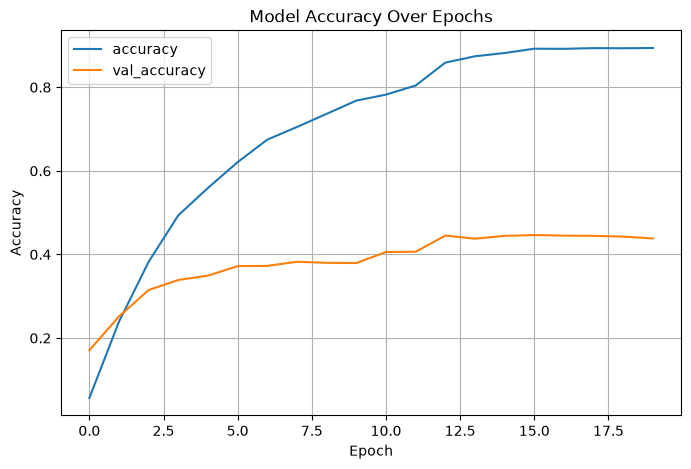

In [21]:
df[['accuracy', 'val_accuracy']].plot(figsize=(8, 5))
plt.title('Model Accuracy Over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.grid(True)
plt.show()

In [22]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_df = pd.read_csv(
    "anno_test.csv",
    header=None,
    names=["image", "x1", "y1", "x2", "y2", "class_id"]
)

# Convert Stanford's 1-based labels to Keras's 0-based labels
test_df["label"] = (test_df["class_id"] - 1).astype(str)
test_df["file_path"] = (
    "../stanford-cars/cars_test/cars_test/" + test_df["image"]
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="file_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=[str(i) for i in range(NUM_CLASSES)],
    shuffle=False
)

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Found 8041 validated image filenames belonging to 196 classes.
252/252 ━━━━━━━━━━━━━━━━━━━━ 68s 270ms/step - accuracy: 0.4553 - loss: 2.2819
Test loss: 2.2819
Test accuracy: 0.4553


In [23]:
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_eval_df = pd.read_csv(
    "anno_train.csv",
    header=None,
    names=["image", "x1", "y1", "x2", "y2", "class_id"]
)

# CSV labels are 1-based; Keras uses 0-based labels
train_eval_df["label"] = (
    train_eval_df["class_id"] - 1
).astype(str)

train_eval_df["file_path"] = (
    "../stanford-cars/cars_train/cars_train/"
    + train_eval_df["image"]
)

eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_eval_generator = eval_datagen.flow_from_dataframe(
    train_eval_df,
    x_col="file_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=[str(i) for i in range(NUM_CLASSES)],
    shuffle=False
)

train_loss, train_accuracy = model.evaluate(train_eval_generator)

print(f"Training loss: {train_loss:.4f}")
print(f"Training accuracy: {train_accuracy:.4f}")

Found 8144 validated image filenames belonging to 196 classes.
255/255 ━━━━━━━━━━━━━━━━━━━━ 52s 205ms/step - accuracy: 0.8837 - loss: 0.5936
Training loss: 0.5936
Training accuracy: 0.8837
